In [1]:
import pandas as pd

df = pd.read_csv("results/week6/proactive_predictions.csv")

false_negatives = df[
    (df["Actual"] == 1) &
    (df["Predicted"] == 0)
]

false_negatives

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Actual,Predicted
169,0,131,66,40,0,34.3,0.196,22,1,1,0
172,4,95,64,0,0,32.0,0.161,31,1,1,0
174,5,136,84,41,88,35.0,0.286,35,1,1,0
186,0,138,60,35,167,34.6,0.534,21,1,1,0
187,3,173,84,33,474,35.7,0.258,22,1,1,0
191,3,129,64,29,115,26.4,0.219,28,1,1,0
201,1,95,82,25,180,35.0,0.233,43,1,1,0
207,0,141,0,0,0,42.4,0.205,29,1,1,0
220,0,104,64,37,64,33.6,0.510,22,1,1,0
223,2,134,70,0,0,28.9,0.542,23,1,1,0


In [2]:
false_negatives.to_csv(
    "results/week6/false_negative_patients.csv",
    index=False
)

In [3]:
false_negatives.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,19.0,2.210526,2.123387,0.000,0.000,2.000,3.000,8.000
Glucose,19.0,130.578947,24.757301,95.000,119.500,129.000,137.000,197.000
BloodPressure,19.0,66.526316,25.244072,0.000,64.000,70.000,81.000,92.000
SkinThickness,19.0,29.368421,24.136672,0.000,12.000,30.000,40.500,99.000
Insulin,19.0,125.736842,165.575710,0.000,0.000,88.000,173.500,600.000
BMI,19.0,34.526316,4.356839,26.400,32.650,34.300,35.350,42.900
DiabetesPedigreeFunction,19.0,0.431737,0.229891,0.161,0.226,0.371,0.562,0.968
Age,19.0,30.315789,11.210375,21.000,22.000,28.000,32.500,62.000
Outcome,19.0,1.000000,0.000000,1.000,1.000,1.000,1.000,1.000
Actual,19.0,1.000000,0.000000,1.000,1.000,1.000,1.000,1.000


In [4]:
diabetic = df[df["Actual"] == 1]

comparison = pd.DataFrame({
    "False Negative Mean": false_negatives.mean(numeric_only=True),
    "All Diabetic Mean": diabetic.mean(numeric_only=True)
})

comparison

,False Negative Mean,All Diabetic Mean
Pregnancies,2.210526,4.419355
Glucose,130.578947,141.596774
BloodPressure,66.526316,68.588710
SkinThickness,29.368421,22.137097
Insulin,125.736842,99.290323
BMI,34.526316,35.171774
DiabetesPedigreeFunction,0.431737,0.570177
Age,30.315789,35.935484
Outcome,1.000000,1.000000
Actual,1.000000,1.000000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/week6/proactive_predictions.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (380, 11)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            4      197             70             39      744  36.7   
1            0      117             80             31       53  45.2   
2            4      142             86              0        0  44.0   
3            6      134             80             37      370  46.2   
4            1       79             80             25       37  25.4   

   DiabetesPedigreeFunction  Age  Outcome  Actual  Predicted  
0                     2.329   31        0       0          1  
1                     0.089   24        0       0          1  
2                     0.645   22        1       1          1  
3                     0.238   46        1       1          1  
4                     0.583   22        0       0          1  


In [6]:
print("="*50)
print("Prediction Summary")
print("="*50)

print("Total Samples:", len(df))
print("Actual Diabetic Patients:", (df["Actual"] == 1).sum())
print("Predicted Diabetic Patients:", (df["Predicted"] == 1).sum())


Prediction Summary
Total Samples: 380
Actual Diabetic Patients: 124
Predicted Diabetic Patients: 246


In [7]:
tp = df[(df["Actual"] == 1) & (df["Predicted"] == 1)]
fn = df[(df["Actual"] == 1) & (df["Predicted"] == 0)]
fp = df[(df["Actual"] == 0) & (df["Predicted"] == 1)]
tn = df[(df["Actual"] == 0) & (df["Predicted"] == 0)]

print("True Positives :", len(tp))
print("False Negatives:", len(fn))
print("False Positives:", len(fp))
print("True Negatives :", len(tn))

True Positives : 105
False Negatives: 19
False Positives: 141
True Negatives : 115


In [8]:
features = [
    "Glucose",
    "BMI",
    "Age",
    "Insulin",
    "BloodPressure",
    "Pregnancies"
]

comparison = pd.DataFrame({
    "True Positive Mean": tp[features].mean(),
    "False Negative Mean": fn[features].mean()
})

comparison["Difference"] = (
    comparison["False Negative Mean"] -
    comparison["True Positive Mean"]
)

print(comparison.round(2))

               True Positive Mean  False Negative Mean  Difference
Glucose                    143.59               130.58      -13.01
BMI                         35.29                34.53       -0.76
Age                         36.95                30.32       -6.64
Insulin                     94.50               125.74       31.23
BloodPressure               68.96                66.53       -2.44
Pregnancies                  4.82                 2.21       -2.61


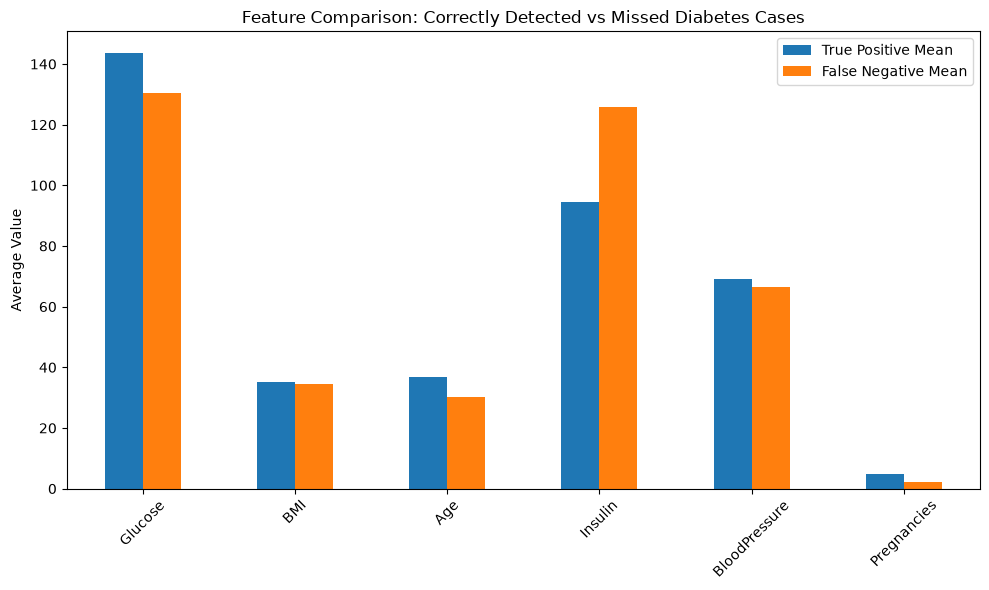

In [9]:
comparison[["True Positive Mean","False Negative Mean"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Feature Comparison: Correctly Detected vs Missed Diabetes Cases")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("results/week6/error_analysis_feature_comparison.png")
plt.show()